![Quantyma Research](logo.png)

**Title:** Scenario-Based Dynamic Modeling Framework for Multi-Vector Hybrid Microgrids in Isolated Amazonian Defense Outposts. 
**Author:** Bruno Priantti  
**Institution:** Quantyma Research  
**Date:** May 2026  
**License:** MIT License  

**Content:**  
This notebook implements the simulation and evaluation framework developed for scenario-based dynamic modeling of multi-vector hybrid microgrids operating under isolated Amazonian conditions.

The proposed environment integrates photovoltaic generation, lithium-ion battery storage (BESS), hydrogen-based seasonal storage, and diesel backup generation within a unified time-series simulation architecture subject to environmental variability and constrained fuel logistics. Synthetic irradiance scenarios are generated using a non-homogeneous Markov chain combined with solar geometry models, while a multi-layer demand synthesis pipeline reproduces the operational variability of remote defense outposts.

The framework is evaluated using a deterministic Rule-Based Controller (RBC) to analyze dispatch behavior, storage dynamics, renewable intermittency, and fuel inventory evolution over continuous annual operating horizons. The resulting simulations enable the identification of operational stress conditions, including battery depletion events, hydrogen saturation periods, and unmet load conditions associated with constrained logistical scenarios.

### params:

In [1]:
from methods import *

PEAK_DEMAND = 3400
YEARS = 5

# SOLAR PV SYSTEM (Designed to generate ~65 kWh during high-irradiance days)
NUM_PANELS = 42
EFFICIENCY = 0.22  # Commercial-grade PV efficiency
AREA = 2.0

# BESS (Lithium-Ion Battery System sized for overnight autonomy)
BESS_CAPACITY_WH = 60000.0   # 60 kWh
BESS_POT_MAX_W = 10000.0     # 10 kW
BESS_INITIAL_SOC = 0.80      # Initial operational state-of-charge

# HYDROGEN STORAGE (Long-duration seasonal energy storage)
H2_CAPACITY_WH = 100000.0    # 100 kWh
H2_POT_MAX_W = 5000.0        # 5 kW
H2_INITIAL_SOC = 0.50        # Initial hydrogen storage level

# DIESEL GENERATOR (Backup generation for critical load support)
DIESEL_CAPACITY_W = 10000.0  # 10 kW backup capacity
DIESEL_TANK_LITERS = 500.0   # Logistic diesel storage capacity
DIESEL_CONSUMPTION_L_PER_KWH = 0.25
THRESHOLD_REFUEL = 50.0      # Refueling alert threshold
FULL_TANK = 500.0

# 8760 simulation steps correspond to one full operational year
n_steps = 8760

### generate solar and demand dinamic and simulation:

In [2]:
database_atmosferic = generate_atmospheric_data_amazon(years=YEARS)
database_final = simulate_military_demand(database_atmosferic, peak_demand_w=PEAK_DEMAND, daily_vol=0.15, hourly_vol=0.10, seed=42)
database_final_test = database_final.loc["2025"]
database_final_test = database_final_test[["G", "Demand"]]

display(database_final_test.head())

,G,Demand
2025-01-01 00:00:00,0.0,1726.370306
2025-01-01 01:00:00,0.0,1709.172350
2025-01-01 02:00:00,0.0,1256.379229
2025-01-01 03:00:00,0.0,1066.047288
2025-01-01 04:00:00,0.0,1512.204426


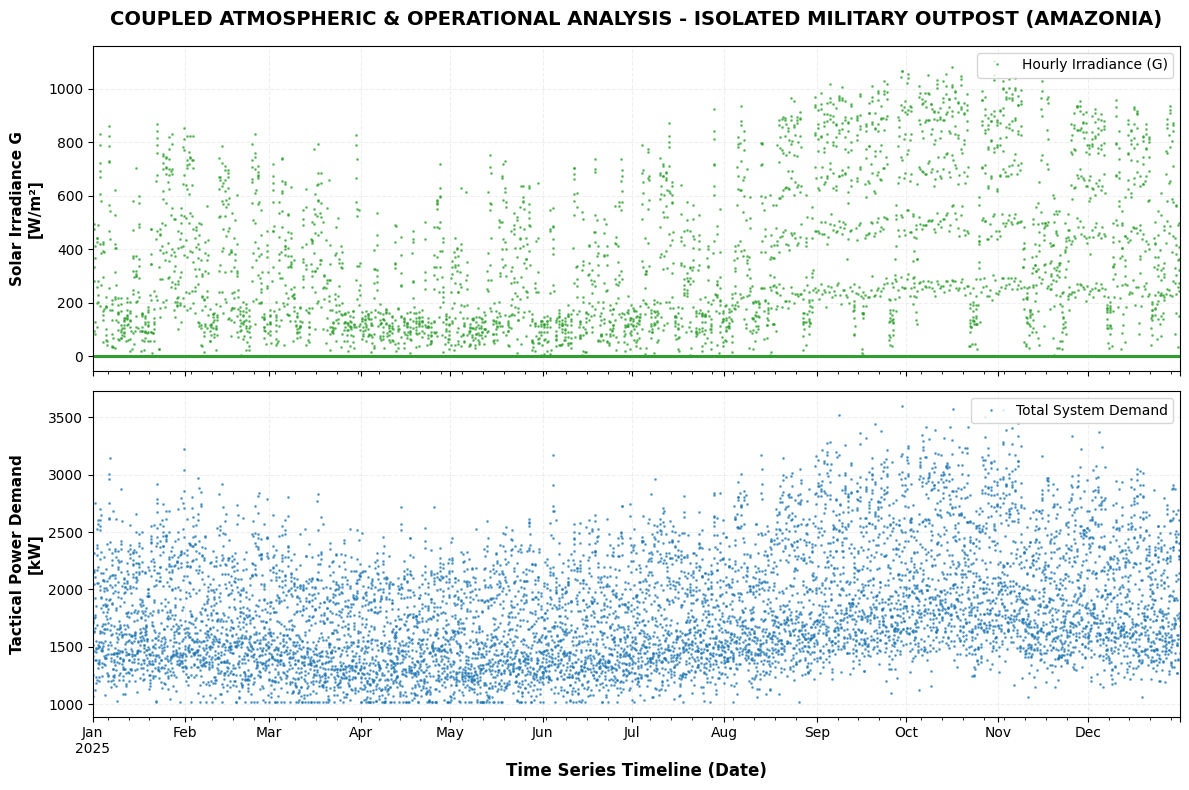

In [3]:
plot_environmental_and_operational_analysis(database_final_test)

#### RBC controler arquitecture:

In [4]:
def rbc_controler(irradiance, demand, bess, h2, diesel):
    
    solar_now = calculate_pure_solar_power(irradiance, NUM_PANELS, EFFICIENCY, AREA)
    net_power = solar_now - demand
    
    st_bess = bess.get_status()
    st_h2 = h2.get_status()
    st_diesel = diesel.get_status()
    
    ordens = {'bess': 0.0, 'h2': 0.0, 'diesel': 0.0}
    
    if net_power > 0:
        ordens['bess'] = min(net_power, st_bess['pot_max_w'])
        saldo_restante = net_power - ordens['bess']
        ordens['h2'] = min(saldo_restante, st_h2['pot_max_w'])
    else:
        deficit = abs(net_power)        
        if st_bess['is_available']:
            pot = min(deficit, st_bess['pot_max_w'])
            ordens['bess'] = -pot
            deficit -= pot
            
        if deficit > 0 and st_h2['is_available']:
            pot = min(deficit, st_h2['pot_max_w'])
            ordens['h2'] = -pot
            deficit -= pot
            
        if deficit > 0 and st_diesel['is_available']:
            ordens['diesel'] = min(deficit, st_diesel['capacity_w'])
            
    return ordens, solar_now, net_power

#### System Dinamic Simulation Though The Time:

In [5]:
diesel_gen = DieselGenerator(
    capacity_w=DIESEL_CAPACITY_W,
    fuel_tank_liters=DIESEL_TANK_LITERS,
    consumption_rate_l_per_kwh=DIESEL_CONSUMPTION_L_PER_KWH
)

bess = BESS(
    cap_energy_wh=BESS_CAPACITY_WH,
    pot_max_w=BESS_POT_MAX_W,
    initial_soc_pct=BESS_INITIAL_SOC
)

h2_system = HydrogenStorage(
    cap_energy_wh=H2_CAPACITY_WH,
    pot_max_w=H2_POT_MAX_W,
    initial_soc_pct=H2_INITIAL_SOC
)

total_refuels = 0
total_diesel_liters_bought = 0

for row in database_final_test.head(n_steps).itertuples():

    # Execute RBC dispatch logic
    ordens,solar_now,net_power = rbc_controler(row.G,row.Demand, bess, h2_system, diesel_gen)

    # Update physical asset states
    p_bess,_ = bess.update_hourly(ordens['bess'])
    p_h2,_ = h2_system.update_hourly(ordens['h2'])
    p_diesel,fuel = diesel_gen.update_hourly(ordens['diesel'])

    # Diesel logistic refueling process
    if diesel_gen.current_fuel_liters <= THRESHOLD_REFUEL:
        liters_needed = FULL_TANK - diesel_gen.current_fuel_liters
        total_diesel_liters_bought += liters_needed
        total_refuels += 1
        diesel_gen.current_fuel_liters = FULL_TANK

    # Compute unmet load during deficit conditions
    if net_power < 0:
        deficit_restante = abs(net_power)-abs(p_bess)-abs(p_h2)-abs(p_diesel)
        unmet_load = max(0.0,deficit_restante)
    else:
        unmet_load = 0.0

    # Collect updated system states
    st_bess = bess.get_status()
    st_h2 = h2_system.get_status()
    st_diesel = diesel_gen.get_status()

    # Store simulation outputs
    database_final_test.at[row.Index,'SOLAR_POWER'] = solar_now
    database_final_test.at[row.Index,'NET_POWER'] = net_power
    database_final_test.at[row.Index,'BESS_POWER_W'] = p_bess
    database_final_test.at[row.Index,'H2_POWER_W'] = p_h2
    database_final_test.at[row.Index,'DIESEL_USAGE_W'] = p_diesel
    database_final_test.at[row.Index,'FUEL_CONSUMED_L'] = fuel

    database_final_test.at[row.Index,'BESS_SOC_WH'] = bess.current_energy_wh
    database_final_test.at[row.Index,'H2_SOC_WH'] = h2_system.current_energy_wh
    database_final_test.at[row.Index,'DIESEL_TANK_L'] = diesel_gen.current_fuel_liters

    database_final_test.at[row.Index,'BESS_AVAIL'] = st_bess['is_available']
    database_final_test.at[row.Index,'H2_AVAIL'] = st_h2['is_available']
    database_final_test.at[row.Index,'DIESEL_AVAIL'] = st_diesel['is_available']

    database_final_test.at[row.Index,'UNMET_LOAD_W'] = unmet_load
    database_final_test.at[row.Index,'IS_BLACKOUT'] = 1 if unmet_load > 0 else 0

# Simulation summary metrics
print("======= SIMULATION COMPLETED =======")
print(f"Total blackout duration: {database_final_test['IS_BLACKOUT'].sum()} h")
print(f"Total fuel consumption: {database_final_test['FUEL_CONSUMED_L'].sum():.2f} Liters")
print(f"Total military refueling operations: {total_refuels}")
print(f"Total purchased diesel volume: {total_diesel_liters_bought:.2f} Liters")

======= SIMULATION COMPLETED =======
Total blackout duration: 120.0 h
Total fuel consumption: 260.61 Liters
Total military refueling operations: 0
Total purchased diesel volume: 0.00 Liters


In [6]:
plot_microgrid_3columns(database_final_test)

3-column subplot successfully updated and saved to: outputs/microgrid_3columns_subplot.png
